# Dask Array (2)

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Dask"
* https://docs.dask.org/en/latest/array.html
* https://gregorygundersen.com/blog/2018/12/10/svd/
* https://en.wikipedia.org/wiki/Cosine_similarity
* https://en.wikipedia.org/wiki/Adjacency_matrix
* https://en.wikipedia.org/wiki/Pairing_function#Cantor_pairing_function
* https://image.dask.org/en/latest/
* https://www.youtube.com/watch?v=-AuwMJAqjJc

## Задачи для совместного разбора

1. Создайте матрицу 100_000x1000 случайных чисел из нормального распределения. Получите SVD-разложение матрицы. Проверьте, что векторы $u_j, j>1$ ортогональны $u_0$. Вычислите длины левых сингулярных векторов.

In [ ]:
import dask.array as da

In [ ]:
arr = da.random.normal(10, 1, size=(1000, 100))

In [ ]:
u, s, v = da.linalg.svd(arr)

In [ ]:
u.shape, s.shape, v.shape

((1000, 100), (100,), (100, 100))

In [ ]:
(u[:, 0] @ u[:, 1]).compute()

array(-6.24500451e-17)

In [ ]:
da.linalg.norm(u[:, 0]).compute()

1.0

2. Сгенерируйте вектор `a` размера 10, заполненный числами из нормального распределения. Пусть `b := -a`. Вычислите косинусное сходство двух этих векторов. Вычислите косинусное сходство каждой пары правых сингулярных векторов из задачи 1.

$$\text{similarity} = \cos(\theta) = {A \cdot B \over \|A\| \|B\|} = \frac{ \sum\limits_{i=1}^{n}{A_i \times B_i} }{ \sqrt{\sum\limits_{i=1}^{n}{(A_i)^2}} \times \sqrt{\sum\limits_{i=1}^{n}{(B_i)^2}} }$$

In [ ]:
a = da.random.normal(0, 1, size=(10, ))
b = -a

In [ ]:
cos = (a @ b) / (da.linalg.norm(a) * da.linalg.norm(b))
cos.compute()

-1.0000000000000002

In [ ]:
da.linalg.norm(v[0]).compute()

1.0000000000000002

In [ ]:
(v @ v.T).compute()

array([[ 1.00000000e+00,  6.17841158e-17,  9.62615449e-17, ...,
         2.95307887e-17, -1.89572292e-17, -4.15152157e-17],
       [ 6.17841158e-17,  1.00000000e+00, -1.01448093e-15, ...,
        -4.99994822e-17, -1.56202805e-16,  5.65444954e-17],
       [ 9.62615449e-17, -1.01448093e-15,  1.00000000e+00, ...,
        -8.60298644e-17, -1.80027281e-16, -3.53931443e-16],
       ...,
       [ 2.95307887e-17, -4.99994822e-17, -8.60298644e-17, ...,
         1.00000000e+00, -1.97891586e-16, -2.00330847e-16],
       [-1.89572292e-17, -1.56202805e-16, -1.80027281e-16, ...,
        -1.97891586e-16,  1.00000000e+00, -4.48454084e-16],
       [-4.15152157e-17,  5.65444954e-17, -3.53931443e-16, ...,
        -2.00330847e-16, -4.48454084e-16,  1.00000000e+00]])

3\. Загрузите изображения из каталога `imgs` при помощи пакета `dask_image`. Визуализируйте одно изображение в цвете и в оттенках серого. Отразите изображение по горизонтали. Визуализируйте исходный и преобразованных вариант на одном рисунке

In [ ]:
import dask_image
from dask_image.imread import imread

In [ ]:
imgs = imread("./data/imgs/*")
imgs

dask.array<_map_read_frame, shape=(11, 512, 384, 3), dtype=uint8, chunksize=(1, 512, 384, 3), chunktype=numpy.ndarray>

In [ ]:
img = imgs[0, :, :, 0].compute()

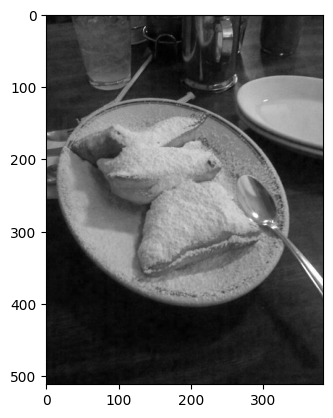

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap="gray")

In [ ]:
from dask_image.ndinterp import affine_transform

In [ ]:
import numpy as np

reflection_matrix = np.array([[1, 0, 0],
                              [0, -1, img.shape[1]-1],
                              [0, 0, 1]])

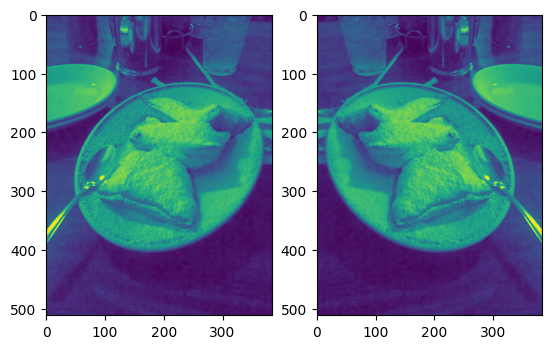

In [ ]:
img_t = affine_transform(img, reflection_matrix).compute()
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(img_t)
ax2.imshow(img)

## Лабораторная работа 8

__При решении данных задач не подразумевается использования циклов или генераторов Python в ходе работы с пакетами `numpy`, `pandas` и `dask`, если в задании не сказано обратного. Решения задач, в которых для обработки массивов `numpy`, структур `pandas` или структур `dask` используются явные циклы (без согласования с преподавателем), могут быть признаны некорректными и не засчитаны.__

В ходе выполнения все операции вычислений (расчет средних значений, расчет косинусной близости и т.д.) проводятся над `dask.array` и средствами пакета `dask` (и `dask_image`), если в задании не сказано обратного. Переход от `dask.array` к `numpy.array` или `pd.DataFrame` возможен исключительно для демонстрации результата в конце решения задачи. Если в задаче используются результаты выполнения предыдущих задач, то подразумевается, что вы используете результаты в виде `dask.array` (то есть то, что было получено до вызова `compute`, а не после).

<p class="task" id="1"></p>

1\. Сингулярным разложением (SVD) матрицы $A$ размера $M\times N$ называется разложение вида $A = USV^\top$, где $U$ - матрица размера $M\times N$  ортонормированных собственных векторов произведения $AA^\top$, $V^T$ - транспонированная матрица размера $N\times N$ ортонормированных собственных  векторов произведения $A^\top A$, $S$ - диагональная матрица сингулярных значений размера $N\times N$.

SVD может быть использовано для понижения размерности векторов. Для этого от матрицы $U$ оставляют первые $k$ столбцов $U_{\cdot,:k}$, от матрицы $S$ оставляют левый верхний квадрат размера $k\times k$ $S_{:k,:k}$ и вычисляется произведение $\hat{A} = U_{\cdot,:k}S_{:k,:k}$

Выберите эмбеддинги тех рецептов, которые относятся к группе с номеров 3 (файл `recipe_embeddings.h5`), и уменьшите их размерность до 64 при помощи реализации алгоритма SVD из пакета `dask.array.linalg`. Выведите количество строк и столбцов полученного массива.

Примечание: после отбора рецепта, принадлежащих третьей группе, вызовите у полученного массива метод `compute_chunk_sizes`, чтобы `dask` обновил метаинформацию в этом массиве.

In [ ]:
import h5py

fp = h5py.File('data/recipe_embeddings.h5', 'r')
embeddings_h5 = fp['embeddings']
mask_h5 = fp['mask']
embeddings = da.from_array(embeddings_h5)
mask = da.from_array(mask_h5)

In [ ]:
from dask_ml.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse=False)
mask_ohe = ohe.fit_transform(mask.reshape(-1, 1))
mask_3 = mask_ohe[:, 3]
embeddings_3 = embeddings[mask_3 == 1]
embeddings_3.compute_chunk_sizes()

def vector_dimension_reduction(arr, k=64):
    u, s, v = da.linalg.svd(arr)
    return da.dot(u[:, :k], da.diag(s[:k]))

embeddings_3_reduced = vector_dimension_reduction(embeddings_3)
embeddings_3_reduced.compute_chunk_sizes()
embeddings_3_reduced.shape

(10000, 64)

<p class="task" id="2"></p>

2\. Используя эмбеддинги уменьшенной размерности, полученные в задании 1, посчитайте косинусное сходство между каждой парой рецептов третьей группы. Выведите матрицу косинусного сходства на экран.

In [ ]:
def cos_similarity_matrix(vectors):
    norm_matrix = da.linalg.norm(vectors, axis=1)
    dot_matrix = vectors @ vectors.T
    cosine_matrix = dot_matrix / norm_matrix[:, None] / norm_matrix[None, :]
    return cosine_matrix

cos_matrix = cos_similarity_matrix(embeddings_3_reduced)
cos_matrix.compute()

/Users/macbook/Library/Python/3.9/lib/python/site-packages/dask/array/routines.py:443: PerformanceWarning: Increasing number of chunks by factor of 12
  out = blockwise(


array([[0.99999979, 0.77996178, 0.7096277 , ..., 0.78566262, 0.72498293,
        0.70748963],
       [0.77996178, 1.00000001, 0.64223851, ..., 0.86709916, 0.61588689,
        0.65344243],
       [0.7096277 , 0.64223851, 1.0000001 , ..., 0.64595654, 0.87130869,
        0.87150222],
       ...,
       [0.78566262, 0.86709916, 0.64595654, ..., 1.00000006, 0.64296746,
        0.66372922],
       [0.72498293, 0.61588689, 0.87130869, ..., 0.64296746, 0.99999985,
        0.91261615],
       [0.70748963, 0.65344243, 0.87150222, ..., 0.66372922, 0.91261615,
        1.00000013]])

<p class="task" id="3"></p>

3\. Используя результат задания 2, посчитайте и выведите на экран количество рецептов, для которых рецепт с индексом `242` входит число топ-5 ближайших рецептов в смысле косинусной близости. При поиске топ-5 рецептов для конкретного рецепта считайте, что он сам в это число не входит.

In [ ]:
top_5 = da.argtopk(cos_matrix, 6, axis=1)[:, 1:]
da.sum(top_5 == 242).compute()

8

<p class="task" id="4"></p>

4\. Графом называется совокупность двух множеств $G=(V,E)$: множества $V=\{v_1, ..., v_M\}$ узлов и множества ребер $E=\{(v_i, v_j)|v_i\in V, v_j\in V\}$, соединяющих эти узлы. Матрицей смежности невзвешенного графа называется квадратная матрица $A=[a_{ij}]$, в которой ${a_{ij}}$ обозначает количество ребер, соединяющих вершины $i$ и $j$.

Постройте матрицу смежности для графа рецептов на основе матрицы косинусного сходства между каждой парой рецептов. Будем считать, что между двумя рецептами в этом графе существует ребро, если косинусное сходство между двумя этими рецептами не менее 0.85. Петли (ребра из вершины в саму в себя) в графе должны отсутствовать. Посчитайте и выведите на экран количество ребер в данном графе. Проверьте, является ли полученная матрица смежности симметричной.

Примечание: считайте, что два различных рецепта не могут иметь косинусное сходство, равное 1.

In [ ]:
adjacency_matrix = (cos_matrix >= 0.85).astype(int)
adjacency_matrix = adjacency_matrix - da.diag(da.diag(adjacency_matrix))
# check if the matrix is symmetric
da.allclose(adjacency_matrix, adjacency_matrix.T).compute()

True

In [ ]:
da.sum(adjacency_matrix).compute()/2

11916385.0

<p class="task" id="5"></p>

5\. В файле `authors_info.hdf5` хранятся два датасета, содержащие информацию возрасте человека и количестве рецептов, оставленных этим человеком. Построите тепловую карту, где по горизонтальной оси откладываются значения количества рецептов, по вертикальной оси - значения количества лет, а на пересечении строк и столбцов указано количество раз, когда человек данного возраста оставил данное кол-во рецептов.

Подсказка: для подсчета количества каждой пары вы можете использовать функцию `da.bincount`. Эта функция не может работать с двумерными массивами, но вы можете закодировать каждую пару уникальным целым числом, например при помощи [этой функции](https://en.wikipedia.org/wiki/Pairing_function#Cantor_pairing_function).

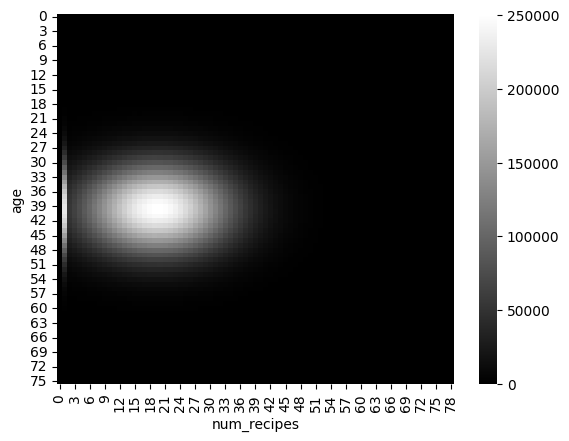

In [ ]:
fp2 = h5py.File('data/authors_info.hdf5', 'r')
age_h5 = fp2['age']
num_recipes_h5 = fp2['num_recipes']
age = da.from_array(age_h5)
num_recipes = da.from_array(num_recipes_h5)

import seaborn as sns

def cantor_pairing(x, y):
    return (x + y) * (x + y + 1) // 2 + y

x = num_recipes
y = age
pairs = cantor_pairing(x, y)
bincount = da.bincount(pairs,  minlength=cantor_pairing(x.max(), y.max()))
bincount.compute_chunk_sizes()

i = da.arange(x.max())
j = da.arange(y.max())
i, j = da.meshgrid(i, j)
index = cantor_pairing(i, j)
heat_map = bincount.vindex[index.compute()]
sns.heatmap(heat_map, cmap="gray")
plt.xlabel("num_recipes")
plt.ylabel("age")
plt.show()

In [ ]:
index.compute()

array([[    0,     1,     3, ...,  2926,  3003,  3081],
       [    2,     4,     7, ...,  3004,  3082,  3161],
       [    5,     8,    12, ...,  3083,  3162,  3242],
       ...,
       [ 2774,  2848,  2923, ..., 11248, 11398, 11549],
       [ 2849,  2924,  3000, ..., 11399, 11550, 11702],
       [ 2925,  3001,  3078, ..., 11551, 11703, 11856]])

In [ ]:
cantor_pairing(x.max(), y.max()).compute()

12166

In [ ]:
import seaborn as sns

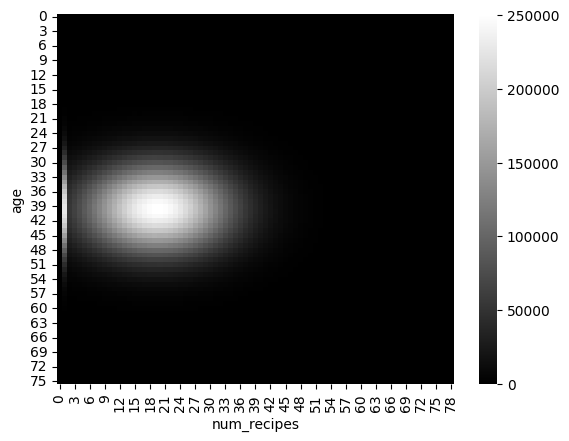

In [ ]:
def cantor_pairing(x, y):
    return (x + y) * (x + y + 1) // 2 + y

x = num_recipes
y = age
pairs = cantor_pairing(x, y)
bincount = da.bincount(pairs,  minlength=cantor_pairing(x.max(), y.max()))
bincount.compute_chunk_sizes()

i = da.arange(x.max())
j = da.arange(y.max())
i, j = da.meshgrid(i, j)
index = cantor_pairing(i, j)
heat_map = bincount.vindex[index.compute()]
sns.heatmap(heat_map, cmap="gray")
plt.xlabel("num_recipes")
plt.ylabel("age")
plt.show()

In [ ]:
i = da.arange(x.max())
j = da.arange(y.max())
da.meshgrid(i, j)

[dask.array<broadcast_to, shape=(76, 79), dtype=int64, chunksize=(76, 79), chunktype=numpy.ndarray>,
 dask.array<broadcast_to, shape=(76, 79), dtype=int64, chunksize=(76, 79), chunktype=numpy.ndarray>]

In [ ]:
i.compute()

array([[ 0,  1,  2, ..., 76, 77, 78],
       [ 0,  1,  2, ..., 76, 77, 78],
       [ 0,  1,  2, ..., 76, 77, 78],
       ...,
       [ 0,  1,  2, ..., 76, 77, 78],
       [ 0,  1,  2, ..., 76, 77, 78],
       [ 0,  1,  2, ..., 76, 77, 78]])

In [ ]:
j.compute()

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 2,  2,  2, ...,  2,  2,  2],
       ...,
       [73, 73, 73, ..., 73, 73, 73],
       [74, 74, 74, ..., 74, 74, 74],
       [75, 75, 75, ..., 75, 75, 75]])

<p class="task" id="6"></p>

6\. В архиве `food` находятся фотографии блюд. Удалите все изображения кроме тех, которые имеют размер 512x512. Загрузите изображения в виде массива `dask.array` при помощи пакета `dask_image`. Выведите на экран основную информацию о полученном массиве. Вычислите среднюю интенсивность трех цветов для каждого пикселя каждого изображения. Полученный трехмерный массив далее интерпретируйте как черно-белые изображения. Визуализируйте одно полученное изображение в черно-белой палитре.

In [ ]:
import os
from PIL import Image
from dask_image.imread import imread

path = 'data/food/'
files = [os.path.join(root, file) for root, dirs, files in os.walk(path) for file in files if file]
size = (512, 512)

for file in files:
    if file.endswith('.jpg'):
        with Image.open(file) as img:
            if img.size != size:
                os.remove(file)

arr = imread(f'{path}*/*.jpg')
arr

dask.array<_map_read_frame, shape=(1735, 512, 512, 3), dtype=uint8, chunksize=(1, 512, 512, 3), chunktype=numpy.ndarray>

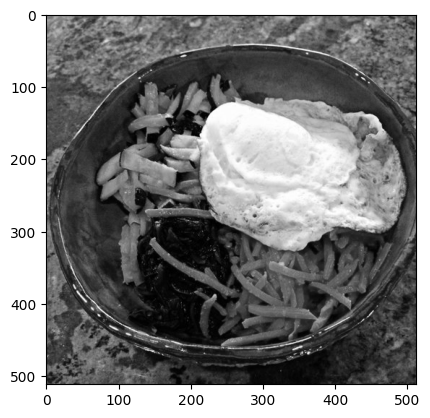

In [ ]:
gray_arr = arr.mean(axis=3)

plt.imshow(gray_arr[-1].compute(), cmap="gray")
plt.show()

<p class="task" id="7"></p>

7\. Добавьте на изображения шум. Для этого сгенерируйте массив, состоящий из нулей и единиц, в котором доля нулей составляет 15%. Выведите на экран среднее значение сгенерированного массива.

Поэлементно умножьте этот массив на каждое черно-белое изображение. На одном рисунке визуализируйте изображение до и после добавления шума. Постройте гистограммы интенсивности пикселей до и после добавления шума.

In [ ]:
noise = da.random.choice([0, 1], size=gray_arr[0].shape, p=[0.15, 0.85])
noise.mean().compute()

0.8502693176269531

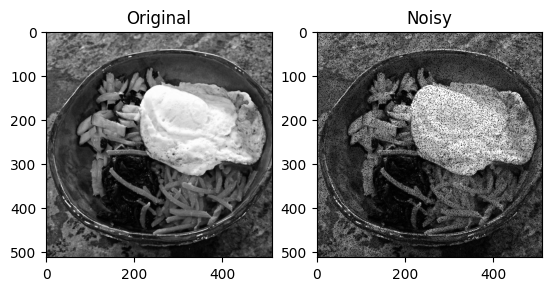

In [ ]:
noisy_arr = gray_arr * noise
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(gray_arr[-1].compute(), cmap="gray")
ax2.imshow(noisy_arr[-1].compute(), cmap="gray")
ax1.set_title("Original")
ax2.set_title("Noisy")
plt.show()

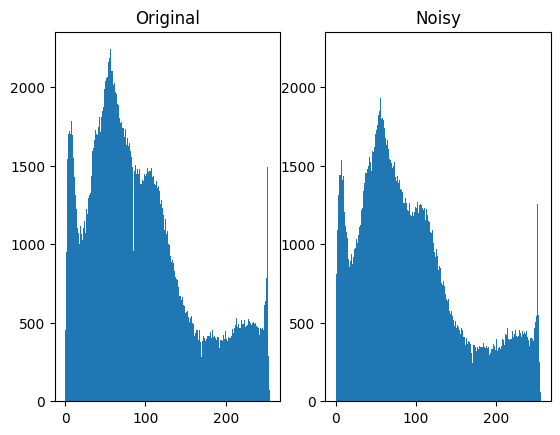

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(gray_arr[-1].ravel().compute(), bins=256)
ax2.hist(noisy_arr[-1].ravel().compute(), bins=256)
ax2.set_ylim(ax1.get_ylim())
ax1.set_title("Original")
ax2.set_title("Noisy")
plt.show()

<p class="task" id="8"></p>

8\. Примените фильтр Гаусса из пакета `dask_image.ndfilters` к черно-белым изображениям. На одном рисунке визуализируйте изображение до и после применения фильтра. Исследуйте, как влияют значения `sigma` и `truncate` на результат. Проверьте не менее трех комбинаций этих параметров.

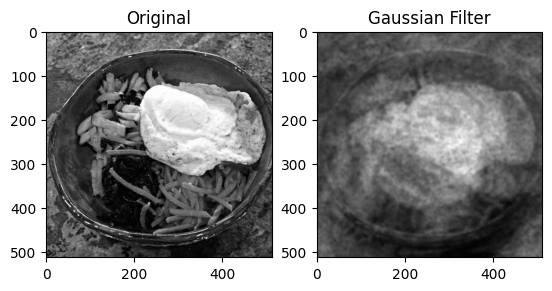

In [ ]:
from dask_image.ndfilters import gaussian_filter

smooth_arr = gaussian_filter(noisy_arr, sigma=2.5, truncate=4)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(gray_arr[-1].compute(), cmap="gray")
ax2.imshow(smooth_arr[-1].compute(), cmap="gray")
ax1.set_title("Original")
ax2.set_title("Gaussian Filter")
plt.show()

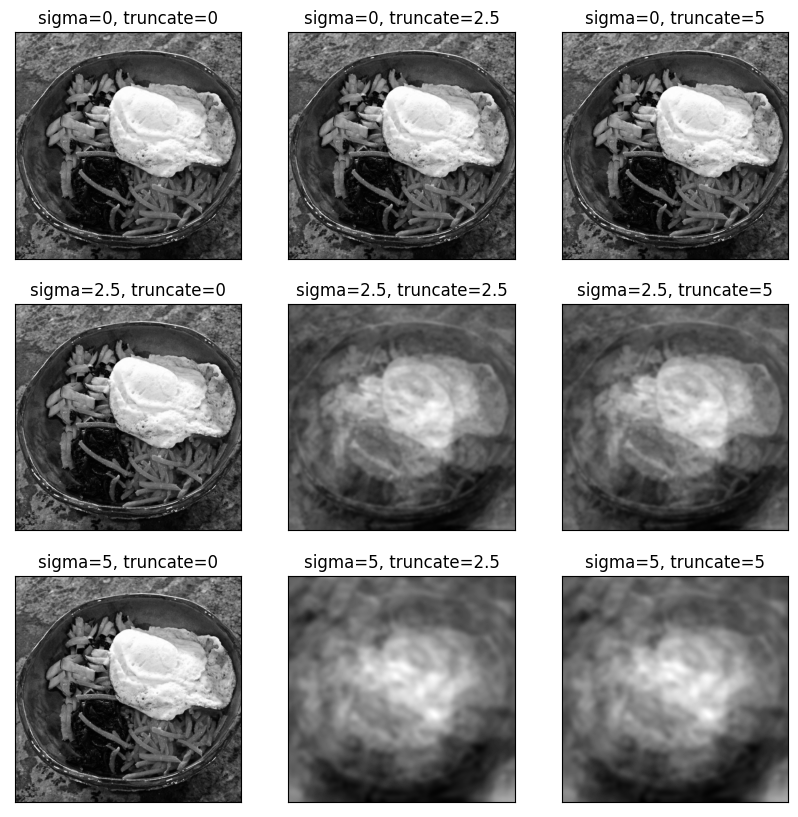

In [ ]:
sigma_list = [0, 2.5, 5]
truncate_list = [0, 2.5, 5]
sigma_truncate = [(sigma, truncate) for sigma in sigma_list for truncate in truncate_list]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for (sigma, truncate), ax in zip(sigma_truncate, axes.ravel()):
    smooth_arr = gaussian_filter(gray_arr, sigma=sigma, truncate=truncate)
    ax.imshow(smooth_arr[-1].compute(), cmap="gray")
    ax.set_title(f"sigma={sigma}, truncate={truncate}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()